<h2>Groover's Search Algorithm</h1>
Grover's search algorithm was first invented by Luv Grover (who was employed at Bell labs) in 1996.

Grover L.K.: A fast quantum mechanical algorithm for database search, Proceedings, 28th Annual ACM Symposium on the Theory of Computing, (May 1996) p. 212

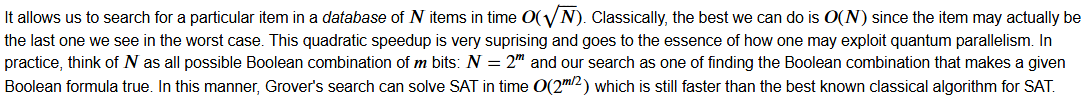

We will describe Grover's algorithm in these notes.

<h4>We will describe Grover's algorithm in these notes.</h4>

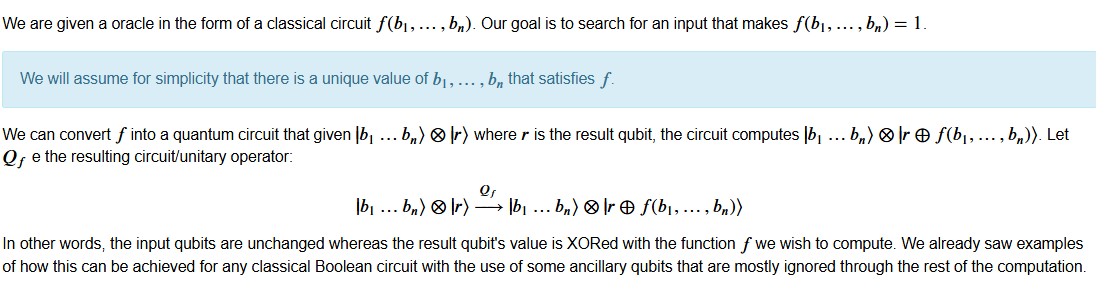

In other terms the f becomes 1 (since resultbit r was set to 0 initially and we are using XOR between f and r)

<h2>Quantum Kickback</h2>
For Grover's search algorithm, we would like to implement an Oracle that "marks" the "correct answer" by negating its amplitude.

<h4>Example</h4>

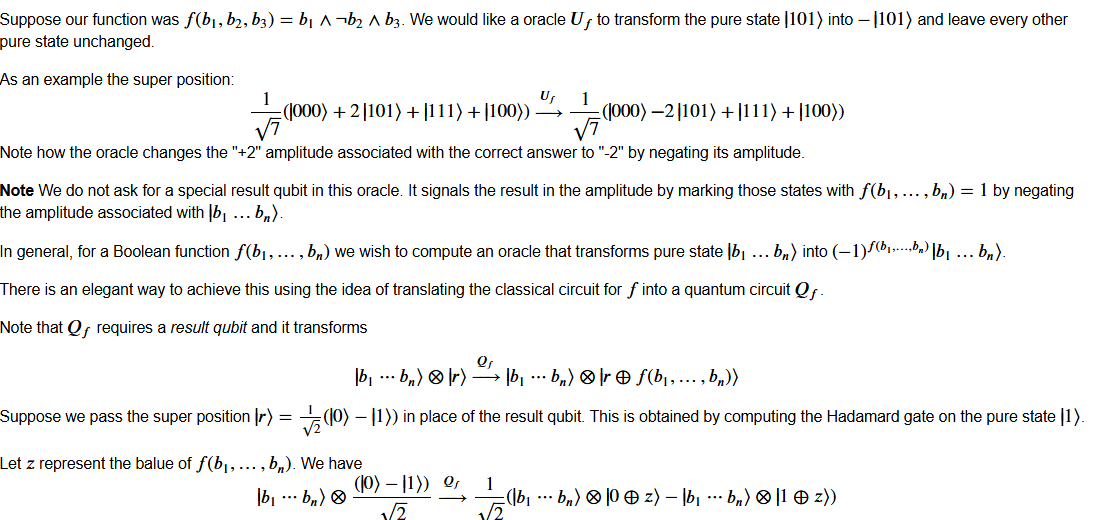
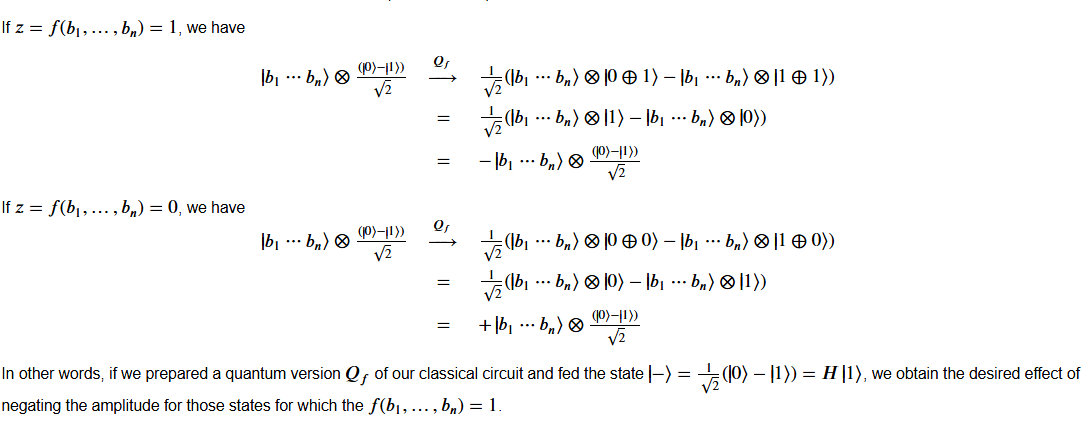
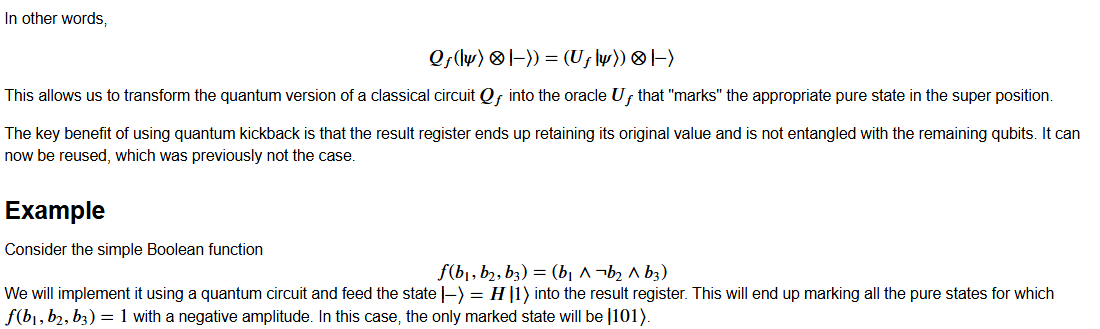

In [17]:

try:
    import qiskit_aer
except:
    !pip3 install qiskit_aer
    import qiskit_aer


try:
    import qiskit.visualization
except:
    !pip3 install 'qiskit[visualization]'
    import qiskit.visualization

    



Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: C:\Users\hramm\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip
ERROR: Invalid requirement: "'qiskit[tools]'": Expected package name at the start of dependency specifier
    'qiskit[tools]'
    ^


ModuleNotFoundError: No module named 'qiskit.tools'

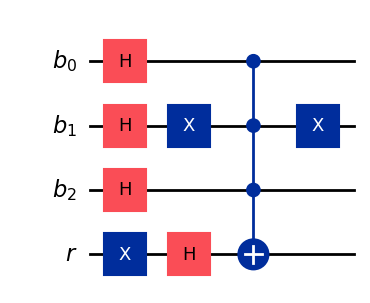

In [6]:
import numpy as np
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister

def create_quantum_circuit():
    inputs = QuantumRegister(3,'b') # input register = 3 qubits
    output = QuantumRegister(1, 'r') # output register = 1 qubit 
    qc = QuantumCircuit(inputs, output)
    # initialize the three gates to a uniform super position (apply Hadamard gate to all 3 qubits - the tensor product of all 3 hardmard will give unifrom superposition)
    qc.h(inputs[0]) # Apply Hadamard gate to qubit 1
    qc.h(inputs[1]) # Apply Hadamard gate to qubit 2
    qc.h(inputs[2]) # Apply Hadamard gate to qubit 3
    # initialize the result register to 1/sqrt(2) ( |0> - |1> )
    qc.x(output[0]) # first apply the not gate to turn it from |0> to |1>
    qc.h(output[0]) # apply hadamard gate 
    ## Now create the circuit for f
    #negage b2
    qc.x(inputs[1])
    # and the three gates into output
    # we will use the multi-controlled x gate with b1, b2, b3 as controls and r as the output
    qc.mcx([inputs[0], inputs[1], inputs[2]], output[0])
    # restore the b2 line back to original value
    qc.x(inputs[1])
    # this is it!!
    return qc 
    
# Let's execute the circuit
qc = create_quantum_circuit()
qc.draw('mpl', style="iqp")


In [8]:
from qiskit import transpile
from qiskit_aer import Aer

# Execute the circuit 
backend = Aer.get_backend('statevector_simulator')
new_circuit = transpile(qc, backend)
job = backend.run(new_circuit)
result = job.result()
statevector = result.get_statevector() # this state vector involves 'r'
# just print the kets corresponding to 'r=|0>'
kets = ['|000>', '|001>', '|010>', '|011>', '|100>', '|101>', '|110>', '|111>' ]
states = [f'({statevector[i]*np.sqrt(2):.8f})' for i in range(8)]
print(' + '.join([s+' '+k for (s,k) in zip(states,kets)]))
# Note: As per requirement the state |101> is marked with a negative value 

(0.35355339+0.00000000j) |000> + (0.35355339+0.00000000j) |001> + (0.35355339+0.00000000j) |010> + (0.35355339+0.00000000j) |011> + (0.35355339+0.00000000j) |100> + (-0.35355339-0.00000000j) |101> + (0.35355339+0.00000000j) |110> + (0.35355339+0.00000000j) |111>


<h2>Grover's Search Algorithm</h2>

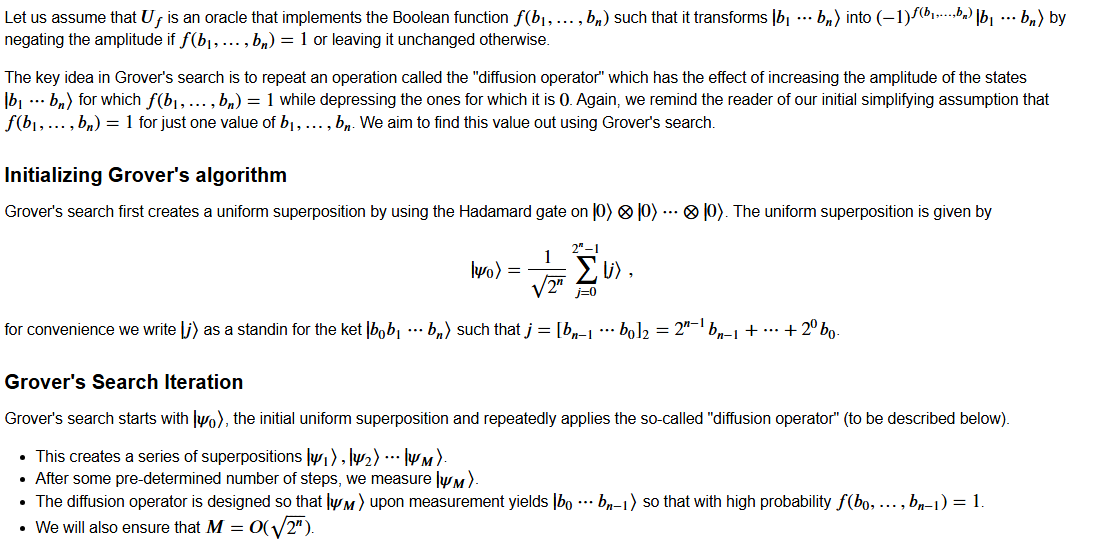

<h2> The Diffusion Operator </h2>

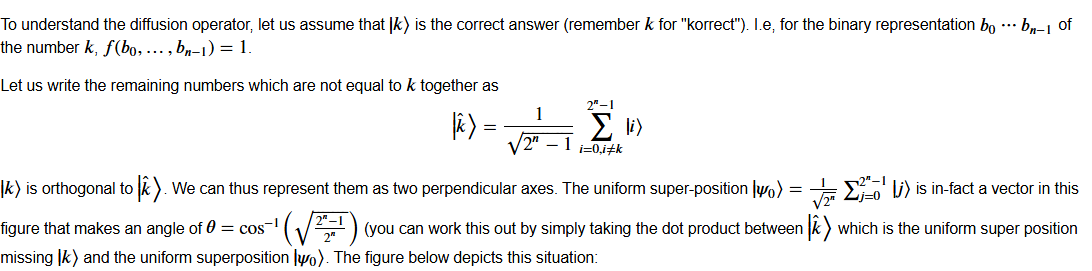

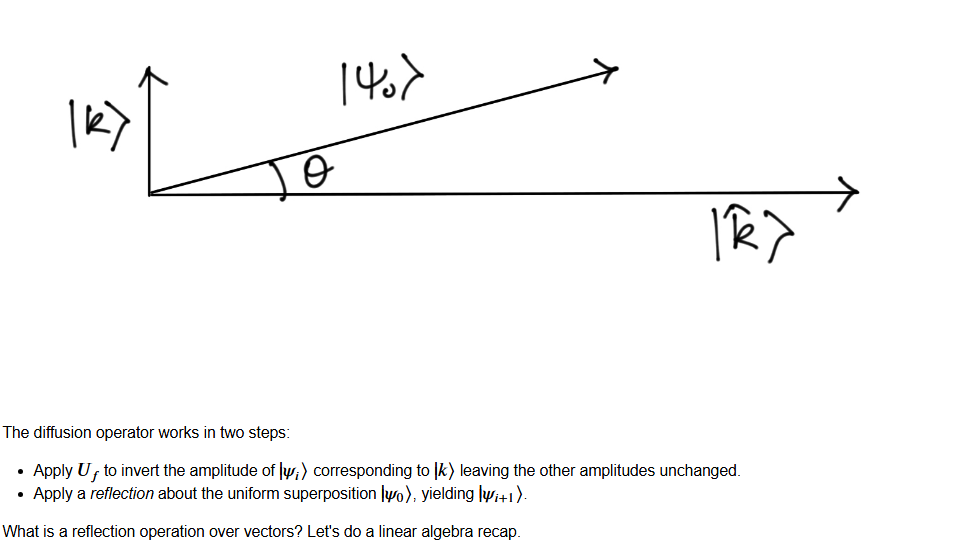

<h2>Reflection Operation (Linear Algebra Recap)</h2>

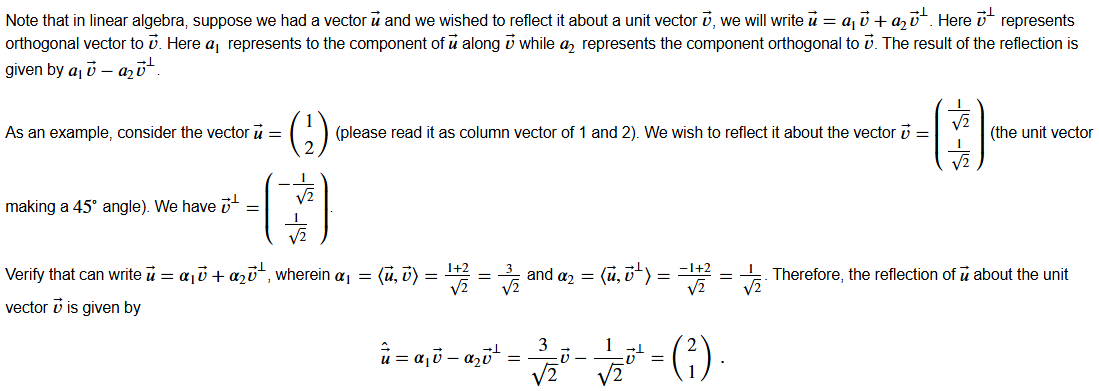
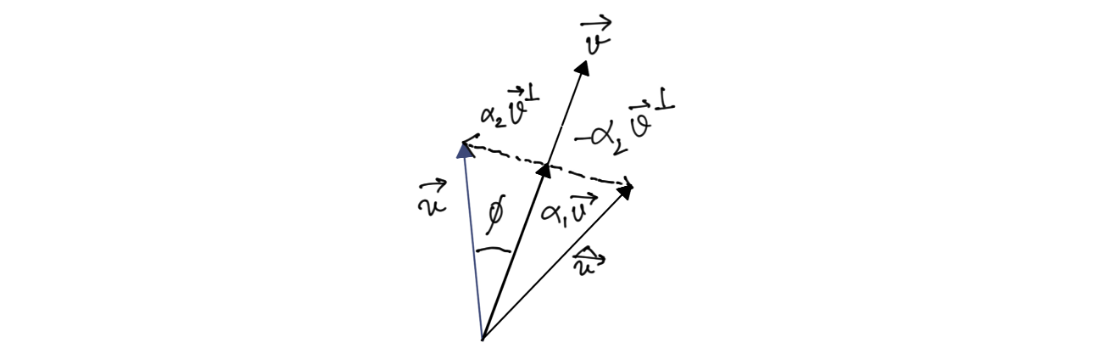

<h2>Diffusion Operator</h2>

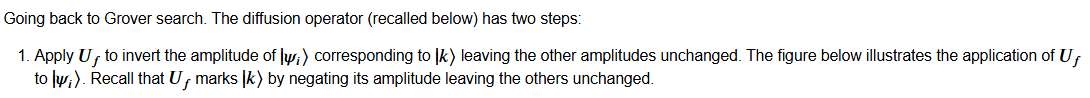
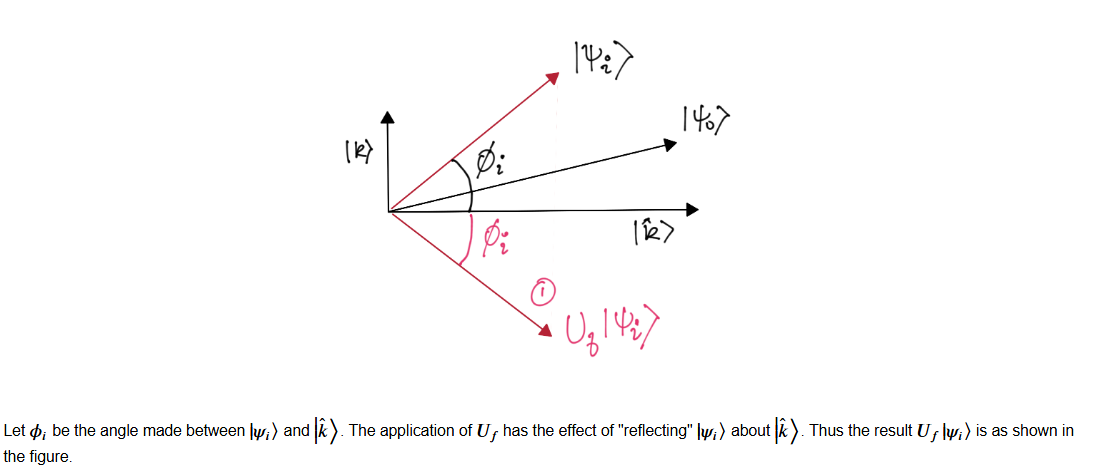
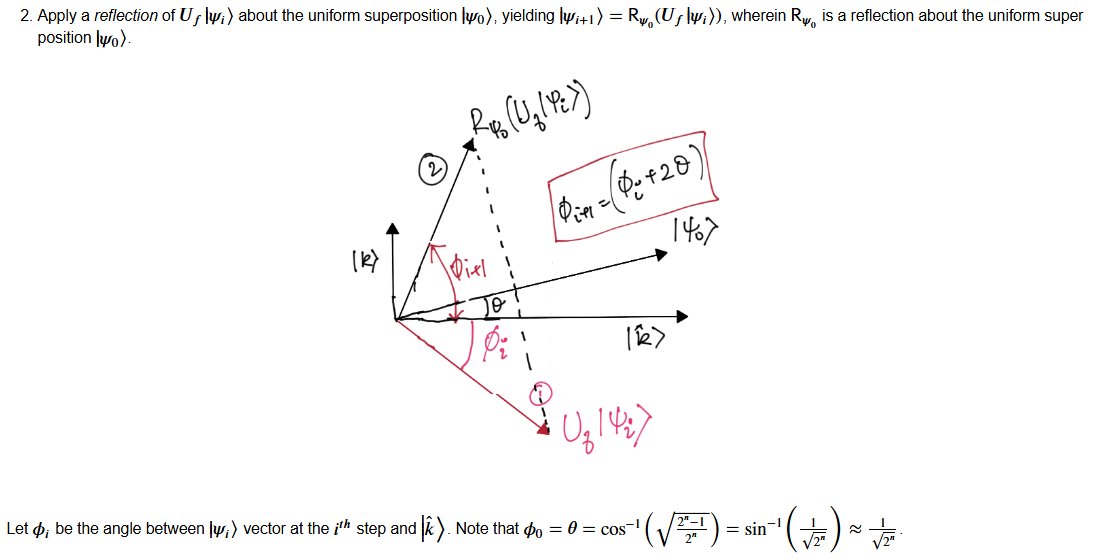
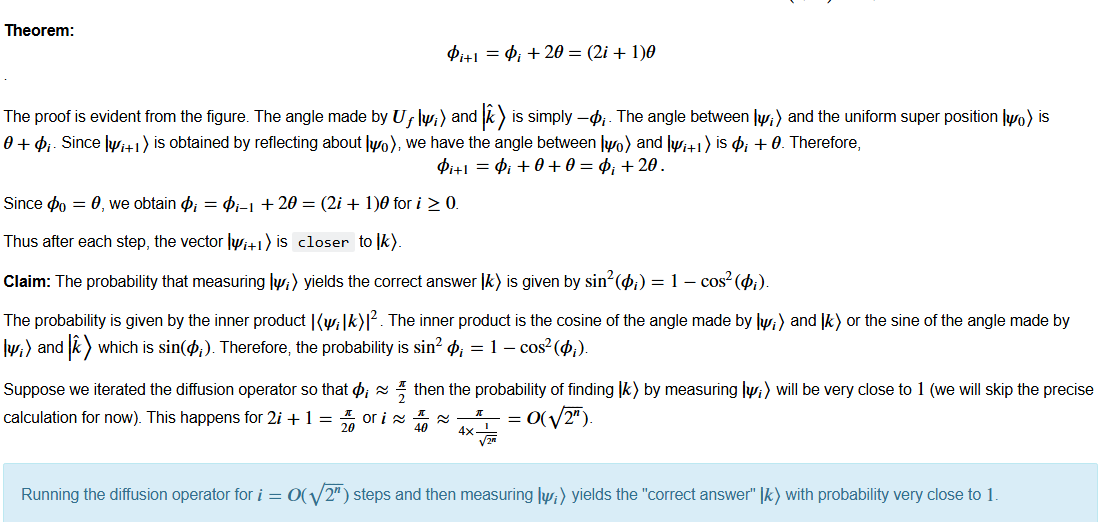

<h2>Implementing the Diffusion Operator</h2>

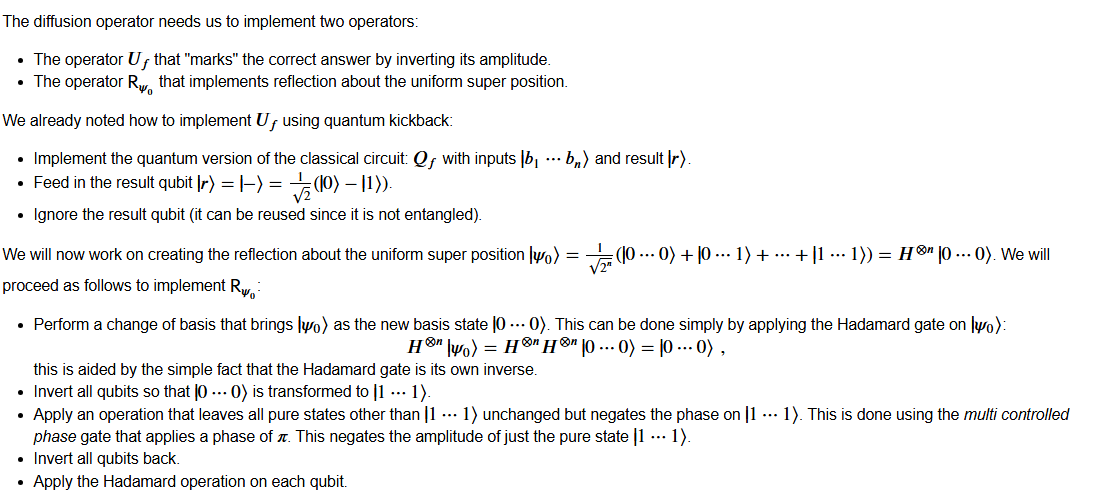

In [10]:
import numpy as np

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit import transpile
from qiskit_aer import Aer

def apply_reflection_about_uniform_state(qc, input_registers): 
    # qc is a previously created quantum circuit
    # input_registers are the registers that measure the input
    # n is the number of input qubits
    # 
    # 1. Apply Hadamard on each of the input registers.
    # 2. Invert all the qubits
    for i in input_registers:
        qc.h(i)
        qc.x(i)
    n = len(input_registers)
    # 3. apply a multi controlled Z gate 
    qc.mcp(np.pi, input_registers[0:n-1], input_registers[n-1])
    for i in input_registers:
        qc.x(i) # invert back
        qc.h(i) # apply Hadamard back
    


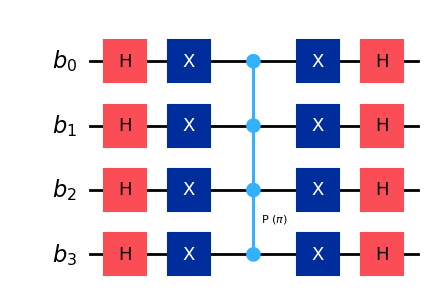

In [11]:
input_registers = QuantumRegister(4, 'b')
qc = QuantumCircuit(input_registers)
apply_reflection_about_uniform_state(qc, input_registers)
qc.draw('mpl', style='iqp')

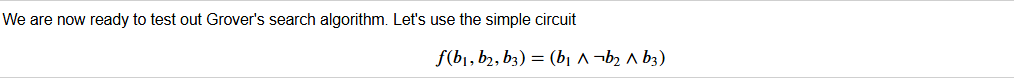

In [13]:
import numpy as np

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit import transpile
from qiskit_aer import Aer

def Uf(qc, inputs, output):
    # copied from the beginning of this lecture
    ## Now create the circuit for f
    #negage b2
    qc.x(inputs[1])
    # and the three gates into output
    # we will use the multi-controlled x gate with b1, b2, b3 as controls and r as the output
    qc.mcx([inputs[0], inputs[1], inputs[2]], output[0])
    # restore the b2 line back to original value
    qc.x(inputs[1])
    # this is it!!

In [14]:
def create_grover_circuit(qc, inputs, result, classical_bits, n_iterations):
    # initialize the three gates to a uniform super position
    qc.h(inputs[0])
    qc.h(inputs[1])
    qc.h(inputs[2])
    # initialize the result register to 1/sqrt(2) ( |0> - |1> )
    qc.x(result[0]) # first apply the not gate to turn it from |0> to |1>
    qc.h(result[0]) # apply hadamard gate 
    for i in range(n_iterations):
        qc.barrier()
        Uf(qc, inputs, result)
        apply_reflection_about_uniform_state(qc, inputs)
    # Now perform a measurement
    qc.measure(inputs, classical_bits)


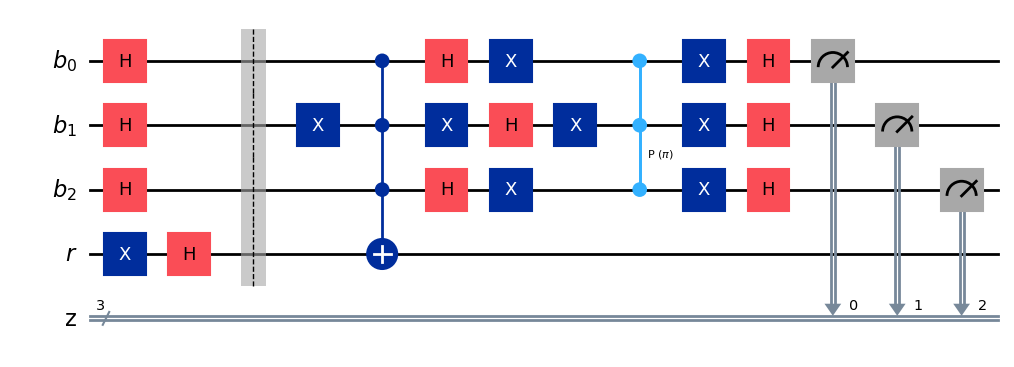

In [15]:
inputs = QuantumRegister(3, 'b')
output = QuantumRegister(1, 'r')
cbit = ClassicalRegister(3, 'z')
qc = QuantumCircuit(inputs, output, cbit)
create_grover_circuit(qc, inputs, output, cbit, 1)
qc.draw('mpl', style="iqp")

Grover Search After One Iteration


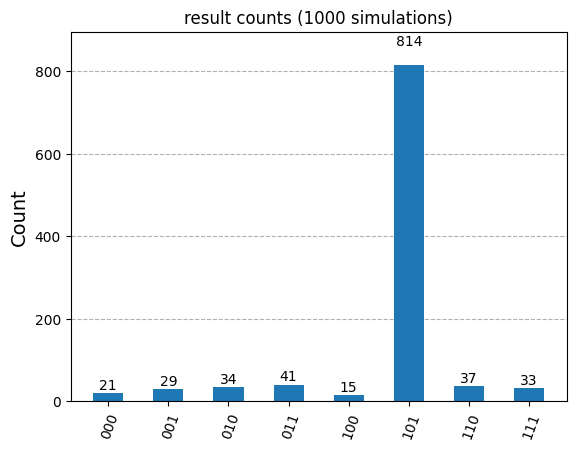

In [18]:
from qiskit.visualization import plot_histogram
print('Grover Search After One Iteration')
# lets test after one iteration
simulator = Aer.get_backend('aer_simulator')
circ = transpile(qc, simulator)


# Run and get counts
result = simulator.run(qc).result()
counts = result.get_counts(circ)
plot_histogram(counts, title='result counts (1000 simulations)')

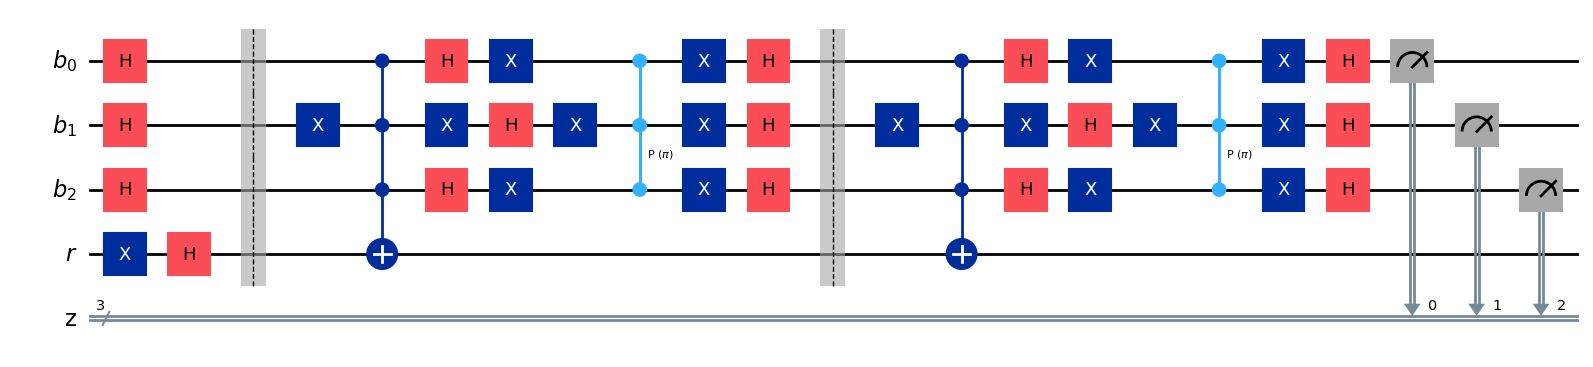

In [19]:
inputs = QuantumRegister(3, 'b')
output = QuantumRegister(1, 'r')
cbit = ClassicalRegister(3, 'z')
qc = QuantumCircuit(inputs, output, cbit)
create_grover_circuit(qc, inputs, output, cbit, 2)
qc.draw('mpl', style="iqp")


Grover Search After Two Iterations


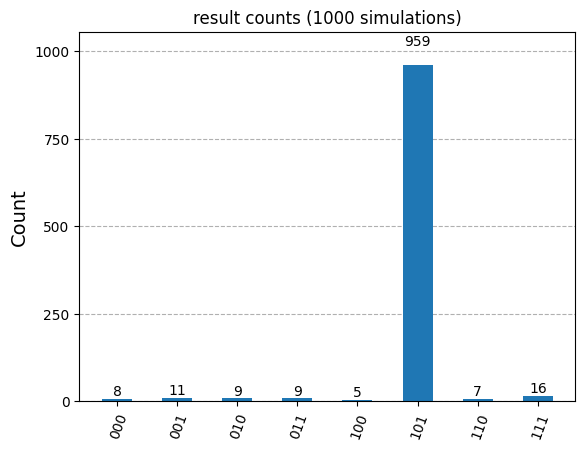

In [20]:
print('Grover Search After Two Iterations')
# lets test after one iteration
simulator = Aer.get_backend('aer_simulator')
circ = transpile(qc, simulator)

# Run and get counts
result = simulator.run(qc).result()
counts = result.get_counts(circ)
plot_histogram(counts, title='result counts (1000 simulations)')

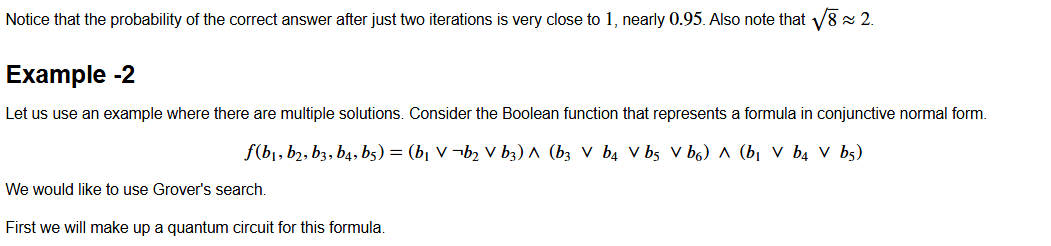

In [22]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, AncillaRegister
from qiskit import transpile
from qiskit_aer import Aer

def implement_clause(qc, inputs, cl, res):
    # go through each clause 
    ctrl_qubits = []
    for idx in cl:
        if idx < 0:
            ctrl_qubits.append(inputs[-idx-1])
        else:
            qc.x(inputs[idx-1])
            ctrl_qubits.append(inputs[idx-1])
    qc.mcx(ctrl_qubits, res)
    qc.x(res)
    for idx in cl:
        if idx > 0:
            qc.x(inputs[idx-1])
    qc.barrier()
    return qc 

def cnf_formula_circuit(qc, inputs, result, clauses):
    # implement a quantum circuit with input qubits, result qubit and a bunch of clauses
    # Use ancillary bits to encode clauses
    a = AncillaRegister(len(clauses)) # add as many as the number of clauses
    qc.add_register(a)
    for (j, cl) in enumerate(clauses):
        # Add an ancillary qubit
        implement_clause(qc, inputs, cl, a[j])
    # implement the and of all the ancillary bits.
    qc.mcx(a, result)
    return qc

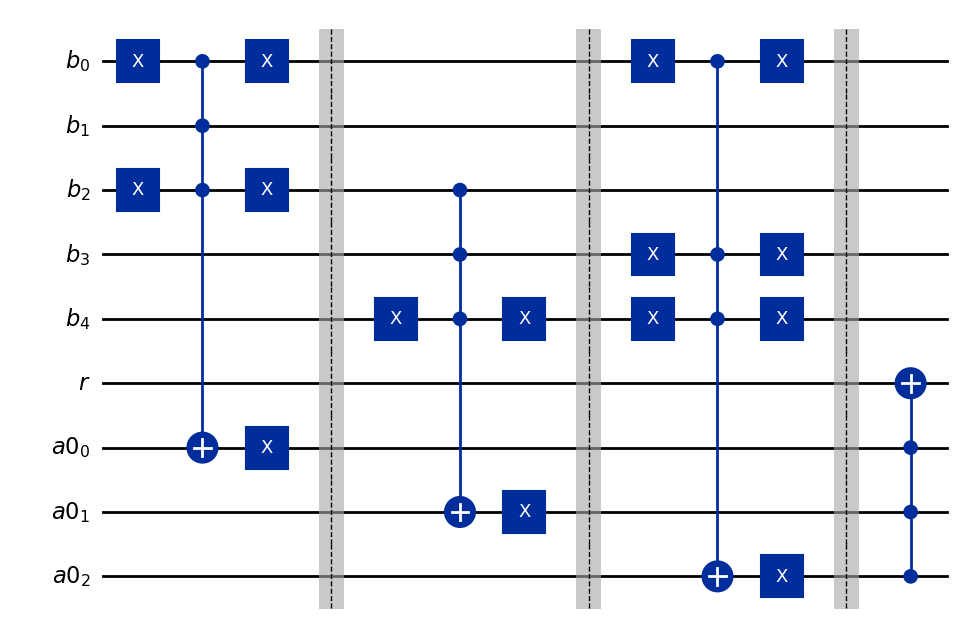

In [23]:
inputs = QuantumRegister(5, 'b')
res = QuantumRegister(1, 'r')
clauses = [ [1, -2, 3], [-3, -4,5], [1, 4, 5]]
qc = QuantumCircuit(inputs, res)
cnf_formula_circuit(qc, inputs, res, clauses)
qc.draw('mpl', style='iqp')

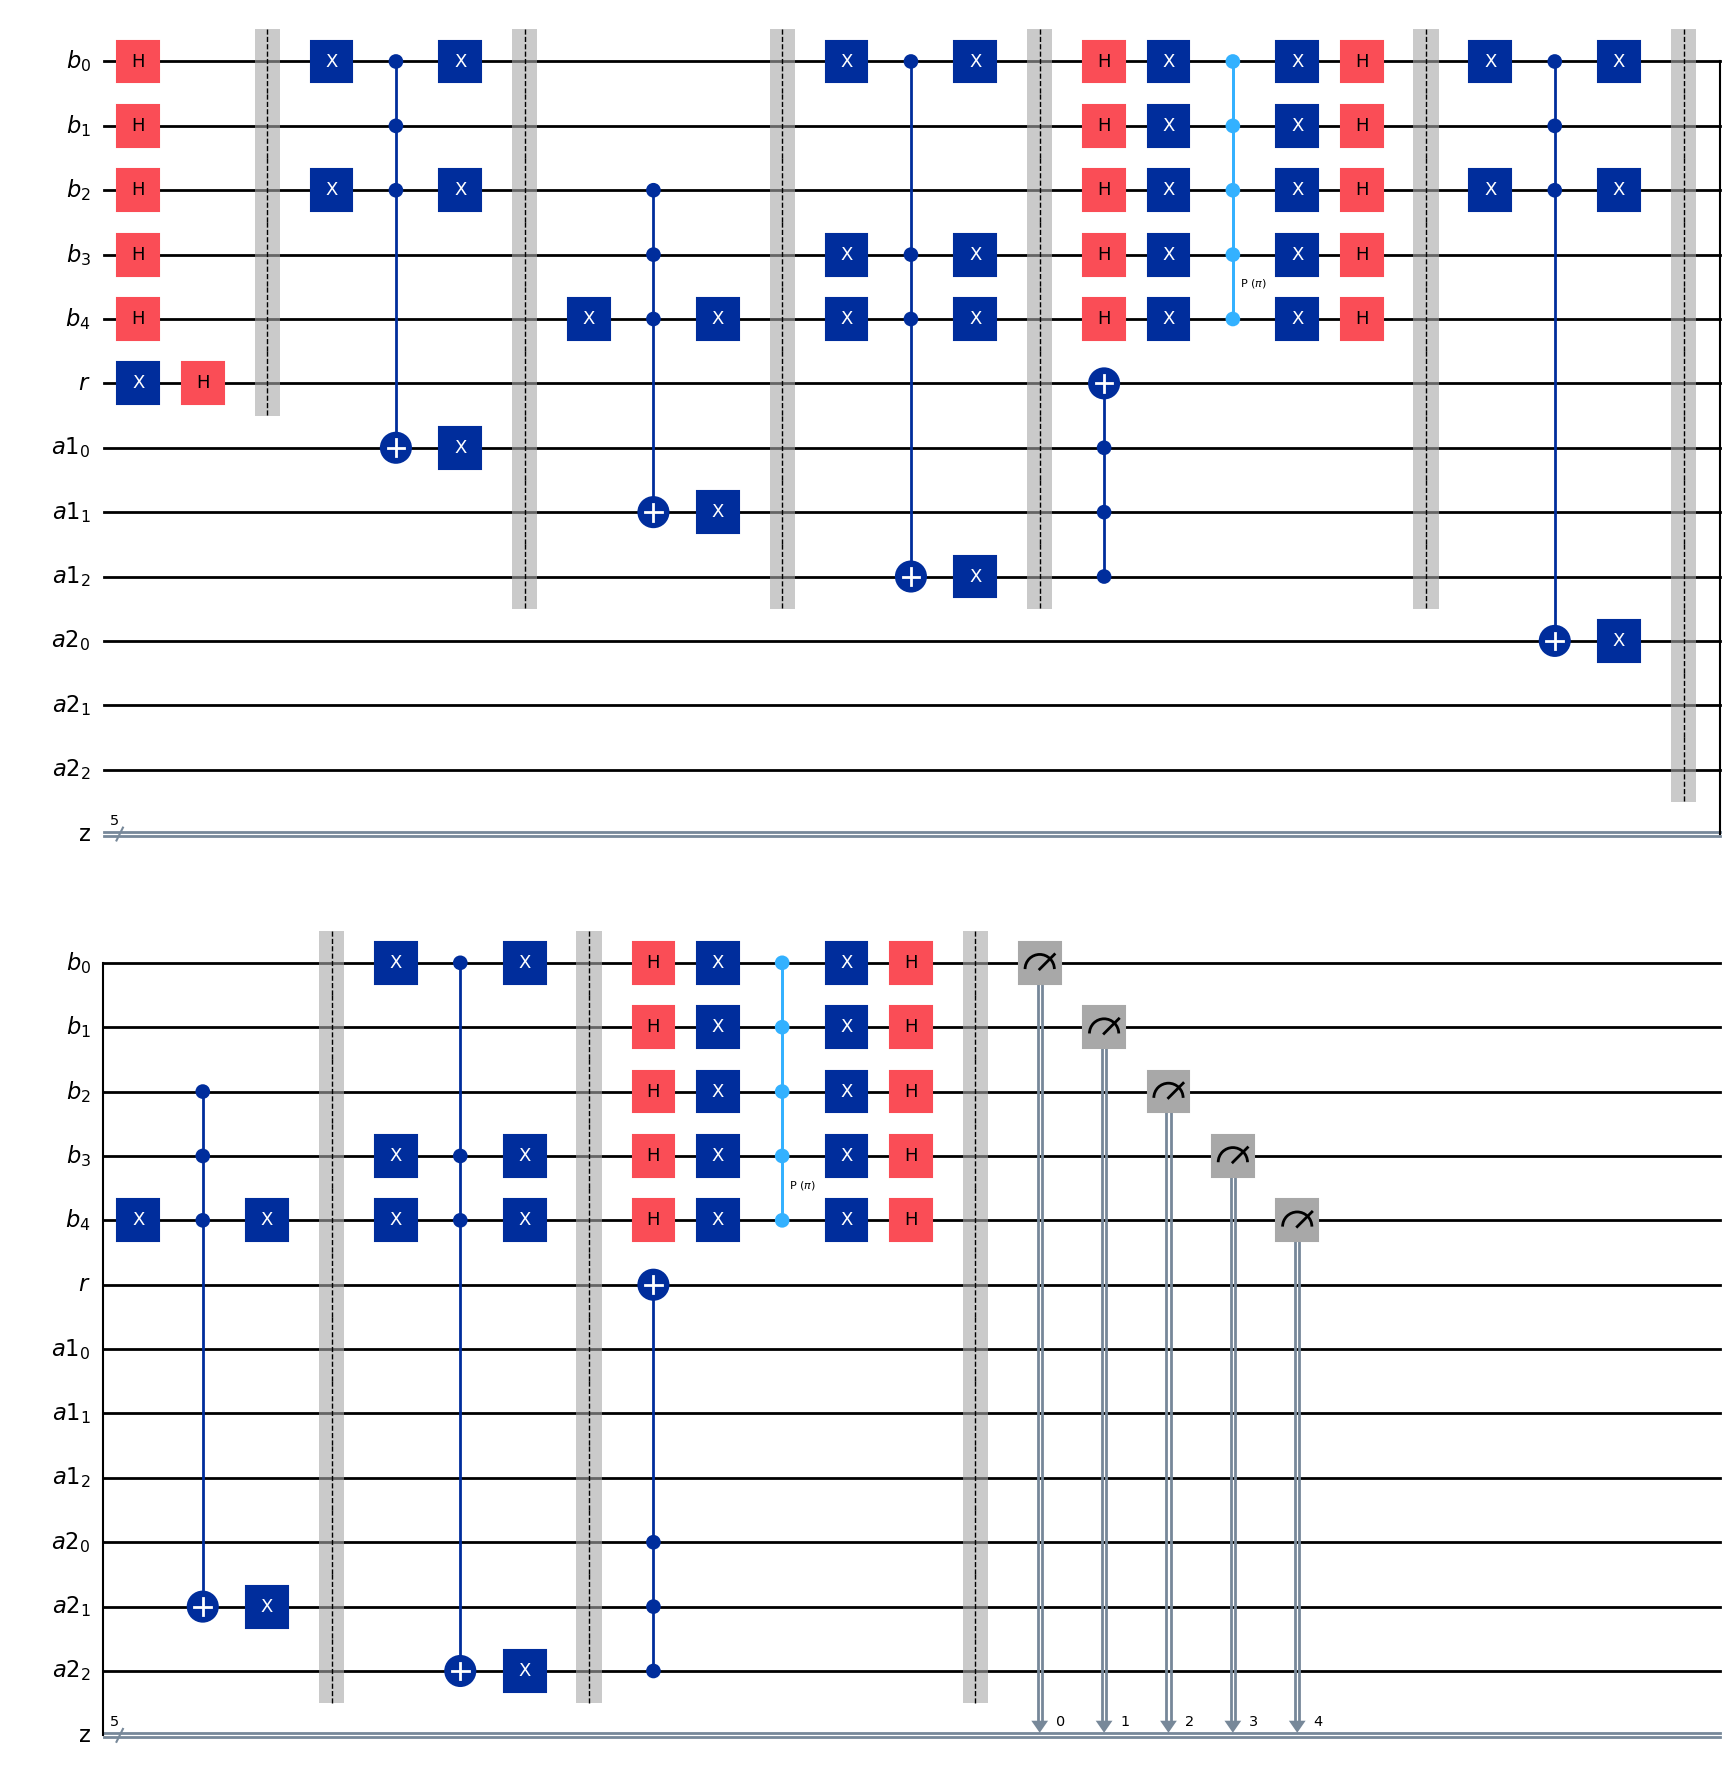

In [24]:
# let's now implement Grover's search to find a value 

def Uf(qc, inputs, output):
    clauses = [ [1, -2, 3], [-3, -4,5], [1, 4, 5]]
    cnf_formula_circuit(qc, inputs, output, clauses)
   
def Grover_diffuse(qc, inputs, output):
    Uf(qc, inputs, output)
    apply_reflection_about_uniform_state(qc, inputs)
    qc.barrier()

def create_quantum_circuit_for_grover(n_iters):
    inputs = QuantumRegister(5, 'b')
    res = QuantumRegister(1, 'r')
    cbit = ClassicalRegister(5, 'z')
    qc = QuantumCircuit(inputs, res, cbit)
    for i in inputs:
        qc.h(i) # apply hadamard
    # now prepare the result register to $|->$
    qc.x(res) # invert it
    qc.h(res) # apply Hadamard
    qc.barrier()
    for i in range(n_iters):
        Grover_diffuse(qc, inputs, res)
    qc.measure(inputs, cbit)
    return qc

qc2 = create_quantum_circuit_for_grover(2)
qc2.draw('mpl', style='iqp')

Grover Search After Two Iterations


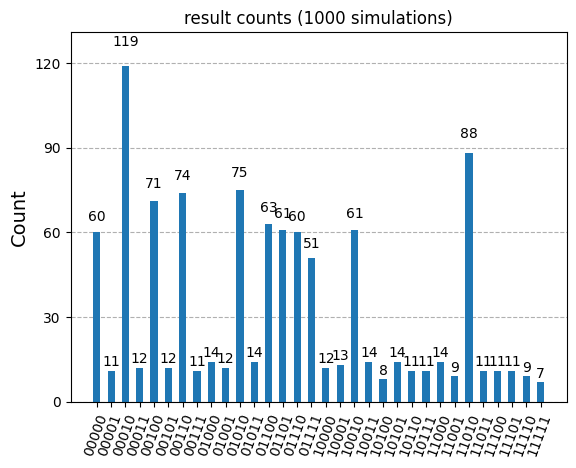

In [26]:
from qiskit.visualization import plot_histogram
print('Grover Search After Two Iterations')
# lets test after one iteration
simulator = Aer.get_backend('aer_simulator')
circ = transpile(qc2, simulator)

# Run and get counts
result = simulator.run(qc2).result()
counts = result.get_counts(circ)
plot_histogram(counts, title='result counts (1000 simulations)')

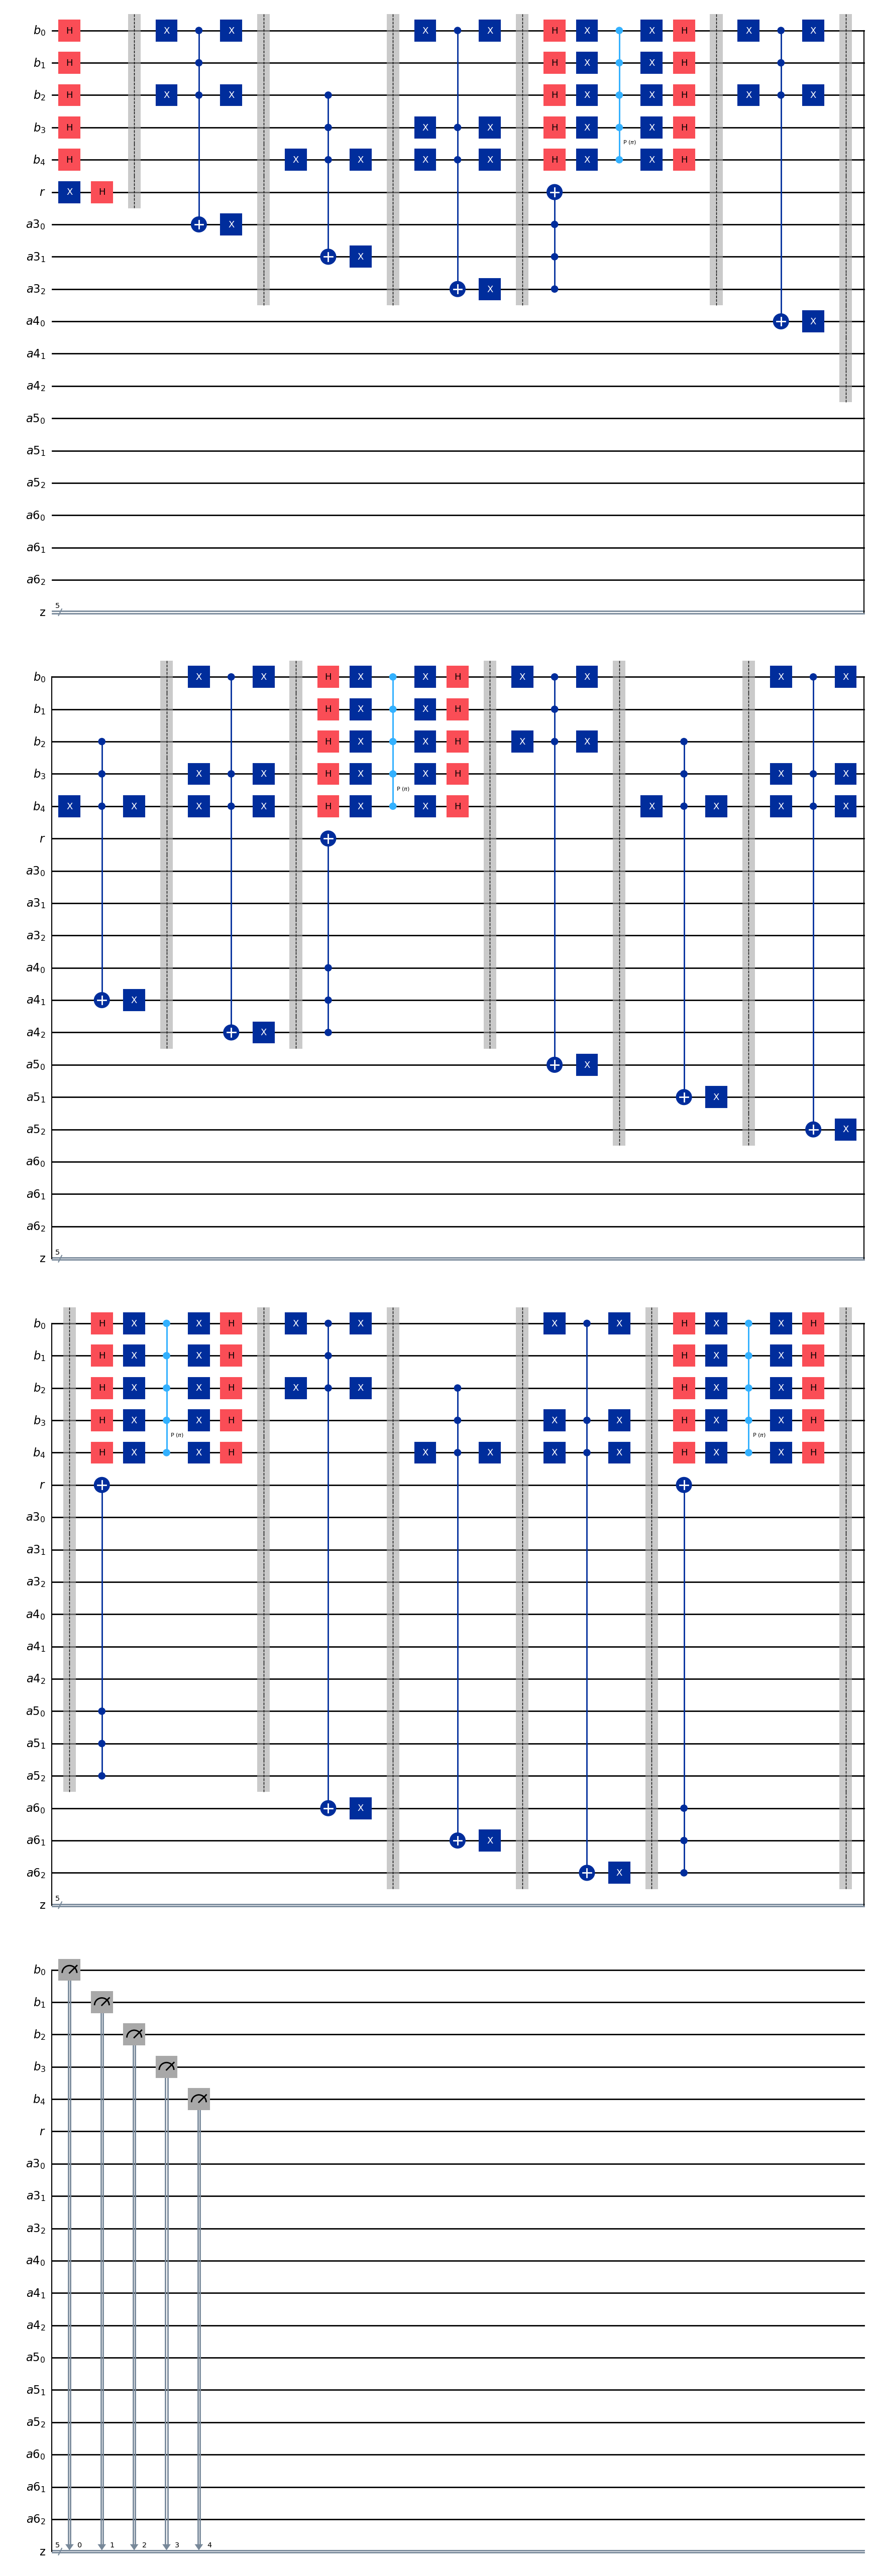

In [27]:
qc4 = create_quantum_circuit_for_grover(4)# 4 iterations of grover's search
qc4.draw('mpl', style='iqp')

Grover Search After Four Iterations


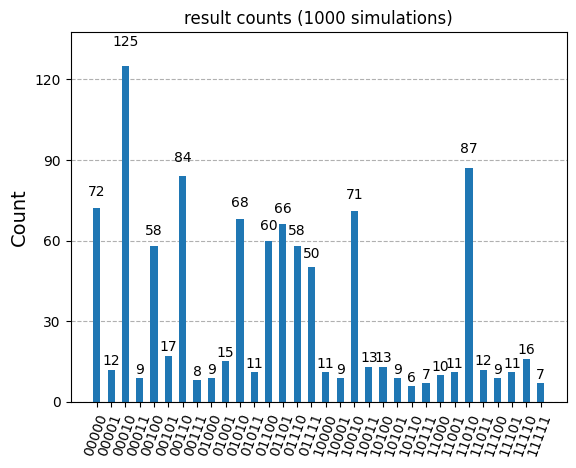

In [29]:
from qiskit.visualization import plot_histogram
print('Grover Search After Four Iterations')
# lets test after one iteration
simulator = Aer.get_backend('aer_simulator')
circ = transpile(qc4, simulator)

# Run and get counts
result = simulator.run(qc4).result()
counts = result.get_counts(circ)
plot_histogram(counts, title='result counts (1000 simulations)')

Notice that Grover's search works: when measured, the output satisfies the formula with a very high probability.
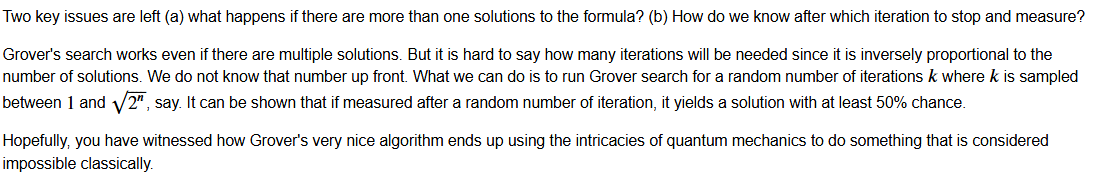

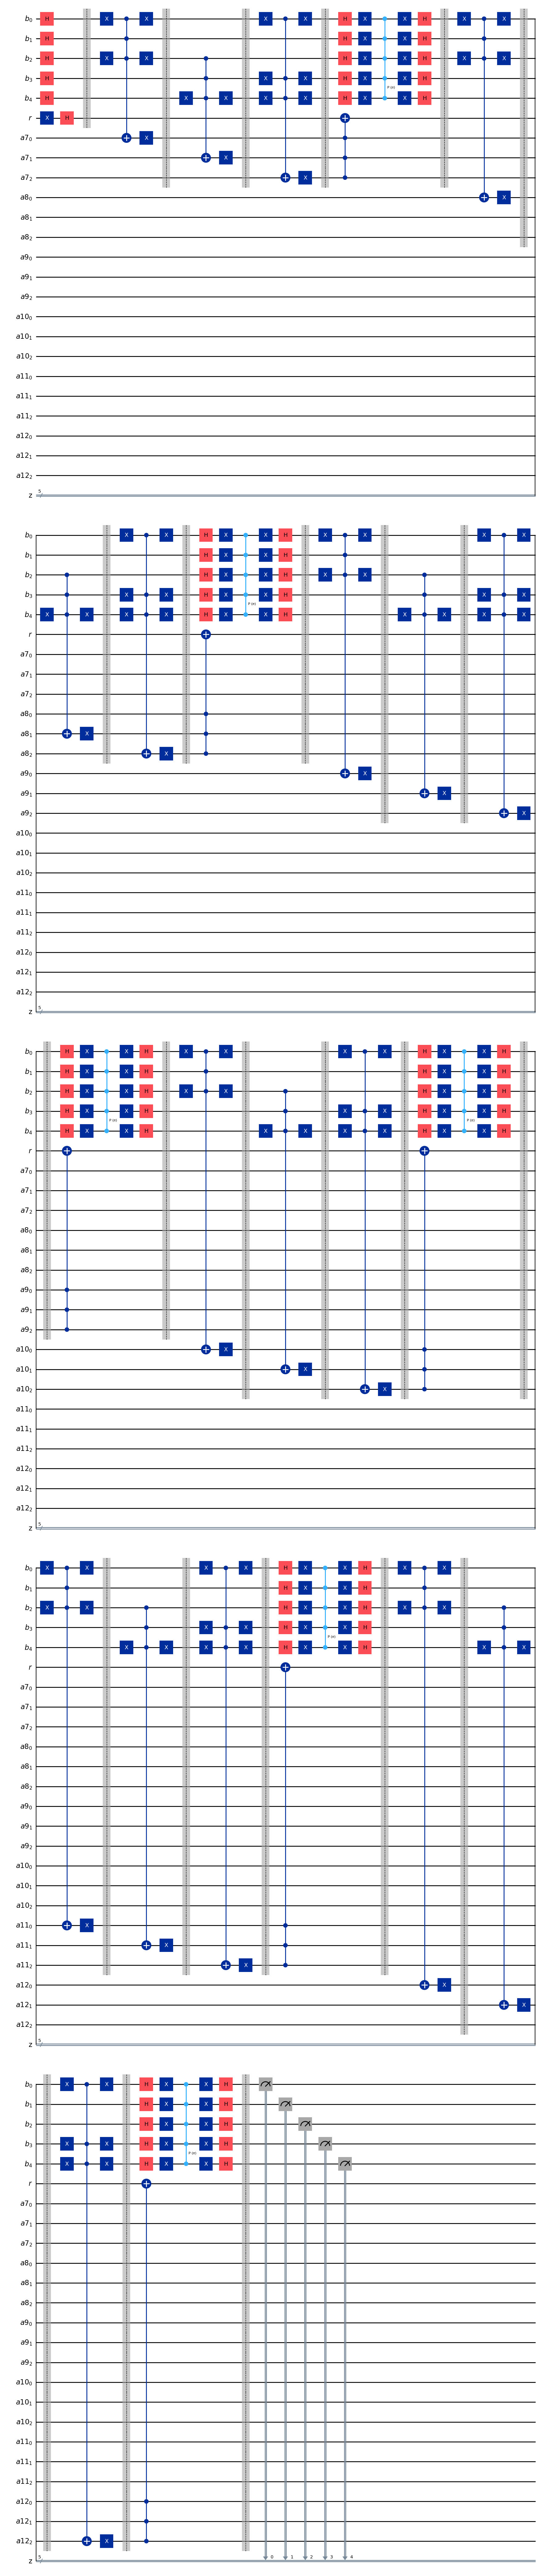

In [30]:
qc6 = create_quantum_circuit_for_grover(6)# 6 iterations of grover's search
qc6.draw('mpl', style='iqp')

Grover Search After Six Iterations


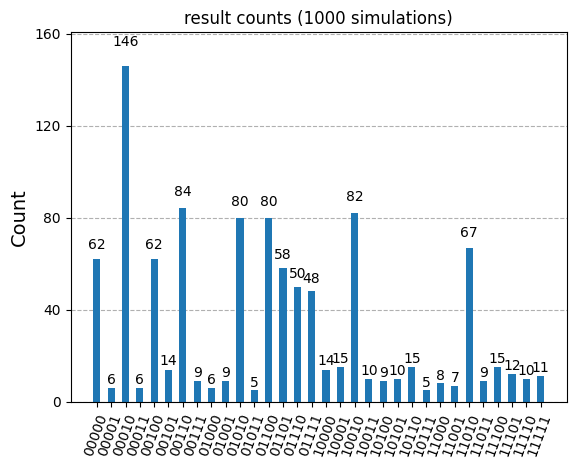

In [31]:
# this will take a long time: run at your own peril !!! 
from qiskit.visualization import plot_histogram
print('Grover Search After Six Iterations')
# lets test after one iteration
simulator = Aer.get_backend('aer_simulator')
circ = transpile(qc6, simulator)

# Run and get counts
result = simulator.run(qc6).result()
counts = result.get_counts(circ)
plot_histogram(counts, title='result counts (1000 simulations)')